In [1]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files


uploaded = files.upload()
filename = list(uploaded.keys())[0]

print(f"Gambar {filename} berhasil diunggah!")

Saving patrickjaneedit.jpg to patrickjaneedit (1).jpg
Gambar patrickjaneedit (1).jpg berhasil diunggah!


/tmp/ipykernel_896/1432007991.py:12: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_gray.ravel(), 256, [0, 256], color='gray')


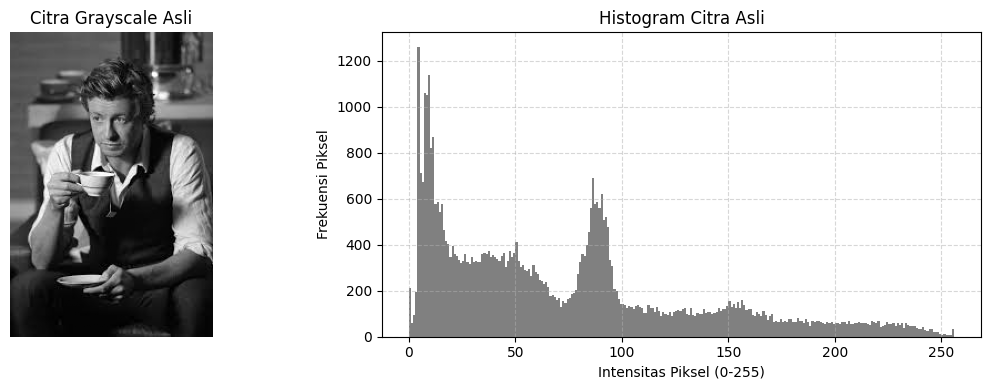

In [2]:

img_gray = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)


plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Citra Grayscale Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.hist(img_gray.ravel(), 256, [0, 256], color='gray')
plt.title('Histogram Citra Asli')
plt.xlabel('Intensitas Piksel (0-255)')
plt.ylabel('Frekuensi Piksel')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

###  Panduan Analisis Histogram Asli (Isi Laporan)

* **Distribusi Piksel:**
  Amati puncak grafik histogram Anda:
  * Jika menumpuk di area **0–80 (kiri)**, artinya gambar cenderung gelap (*underexposed*).
  * Jika menumpuk di area **180–255 (kanan)**, gambar cenderung terang (*overexposed*).
  * Jika berkumpul sempit di **tengah**, gambar memiliki kontras rendah.
  * Jika menyebar luas dari **0 sampai 255**, gambar memiliki kontras tinggi.

* **Alasan Teknis:**
  Tuliskan nilai rentang spesifik di mana mayoritas intensitas piksel berkumpul untuk membuktikan analisis di atas.

/tmp/ipykernel_896/3005286123.py:16: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[0, 1].hist(img_dark.ravel(), 256, [0, 256], color='gray')
/tmp/ipykernel_896/3005286123.py:25: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1, 1].hist(img_bright.ravel(), 256, [0, 256], color='gray')


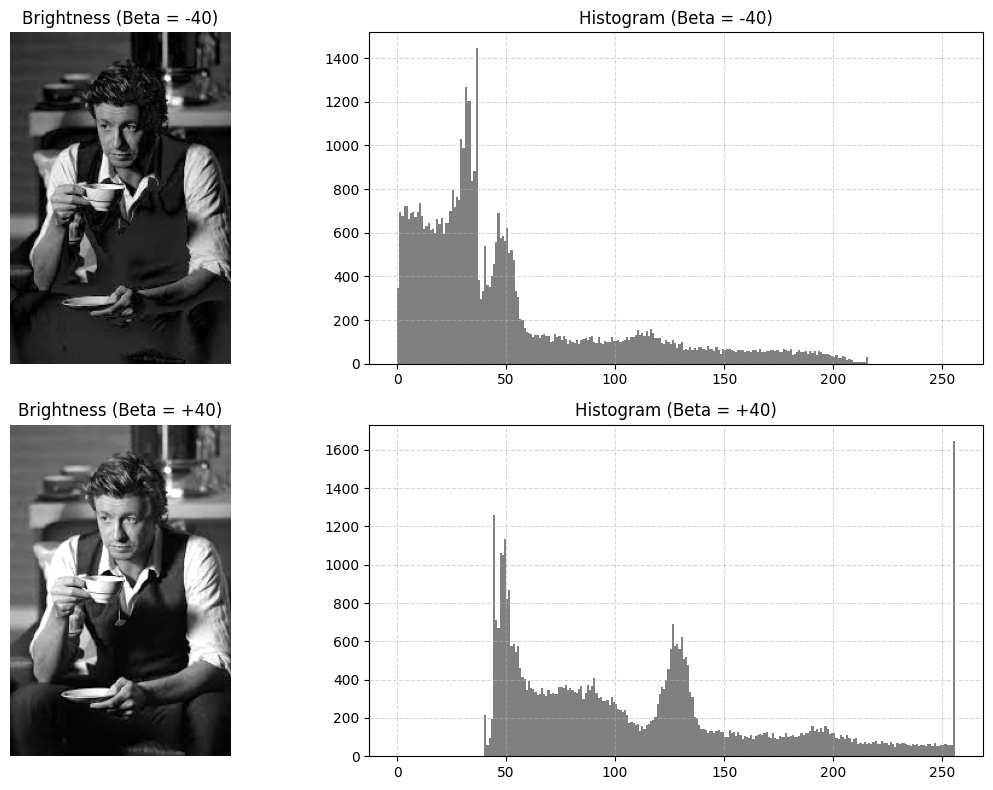

In [3]:

beta_gelap = -40
beta_terang = 40


img_dark = cv2.convertScaleAbs(img_gray, alpha=1.0, beta=beta_gelap)
img_bright = cv2.convertScaleAbs(img_gray, alpha=1.0, beta=beta_terang)


fig, axes = plt.subplots(2, 2, figsize=(12, 8))


axes[0, 0].imshow(img_dark, cmap='gray')
axes[0, 0].set_title(f'Brightness (Beta = {beta_gelap})')
axes[0, 0].axis('off')

axes[0, 1].hist(img_dark.ravel(), 256, [0, 256], color='gray')
axes[0, 1].set_title(f'Histogram (Beta = {beta_gelap})')
axes[0, 1].grid(True, linestyle='--', alpha=0.5)


axes[1, 0].imshow(img_bright, cmap='gray')
axes[1, 0].set_title(f'Brightness (Beta = +{beta_terang})')
axes[1, 0].axis('off')

axes[1, 1].hist(img_bright.ravel(), 256, [0, 256], color='gray')
axes[1, 1].set_title(f'Histogram (Beta = +{beta_terang})')
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

/tmp/ipykernel_896/3135302495.py:16: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[0, 1].hist(img_low_contrast.ravel(), 256, [0, 256], color='gray')
/tmp/ipykernel_896/3135302495.py:25: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1, 1].hist(img_high_contrast.ravel(), 256, [0, 256], color='gray')


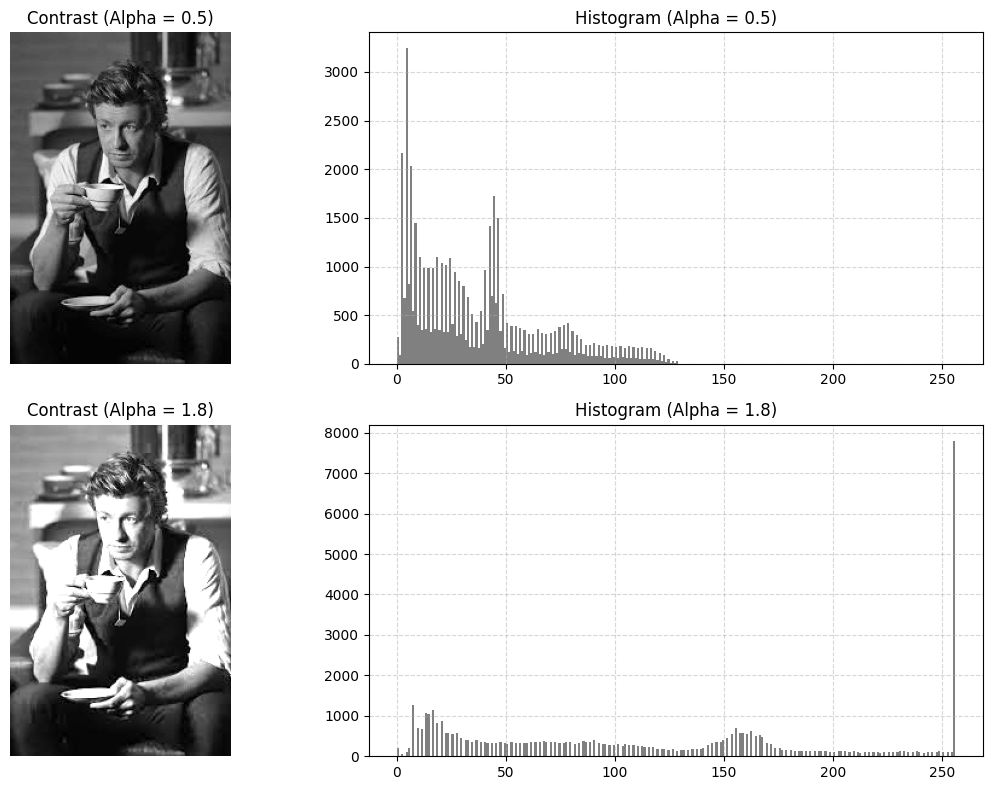

In [4]:

alpha_rendah = 0.5
alpha_tinggi = 1.8


img_low_contrast = cv2.convertScaleAbs(img_gray, alpha=alpha_rendah, beta=0)
img_high_contrast = cv2.convertScaleAbs(img_gray, alpha=alpha_tinggi, beta=0)


fig, axes = plt.subplots(2, 2, figsize=(12, 8))


axes[0, 0].imshow(img_low_contrast, cmap='gray')
axes[0, 0].set_title(f'Contrast (Alpha = {alpha_rendah})')
axes[0, 0].axis('off')

axes[0, 1].hist(img_low_contrast.ravel(), 256, [0, 256], color='gray')
axes[0, 1].set_title(f'Histogram (Alpha = {alpha_rendah})')
axes[0, 1].grid(True, linestyle='--', alpha=0.5)


axes[1, 0].imshow(img_high_contrast, cmap='gray')
axes[1, 0].set_title(f'Contrast (Alpha = {alpha_tinggi})')
axes[1, 0].axis('off')

axes[1, 1].hist(img_high_contrast.ravel(), 256, [0, 256], color='gray')
axes[1, 1].set_title(f'Histogram (Alpha = {alpha_tinggi})')
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

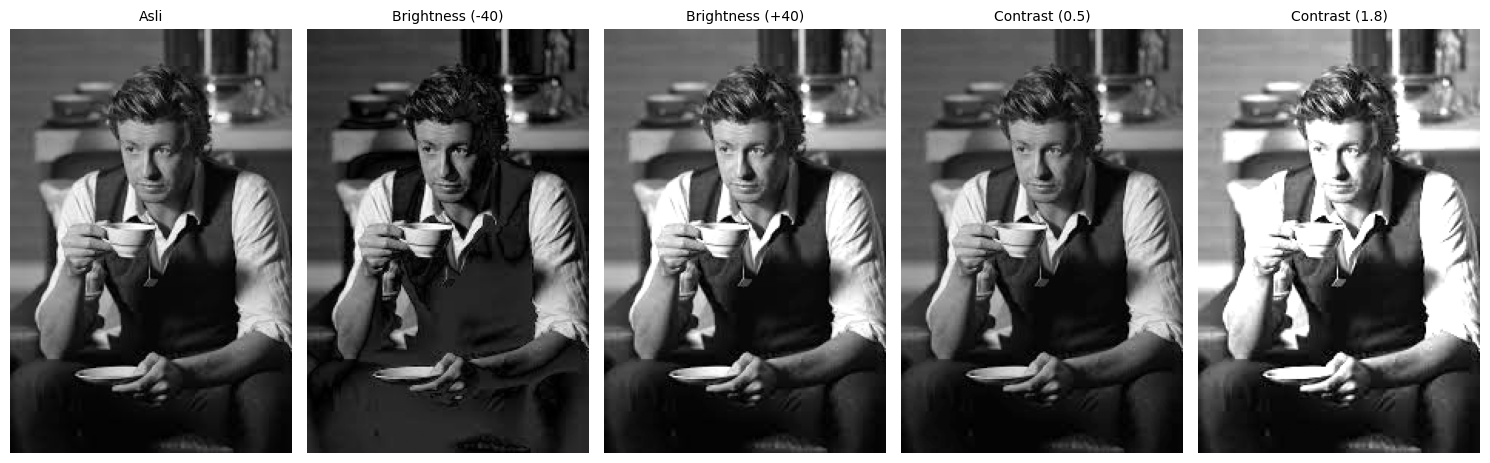

In [5]:

titles = [
    'Asli',
    f'Brightness ({beta_gelap})', f'Brightness (+{beta_terang})',
    f'Contrast ({alpha_rendah})', f'Contrast ({alpha_tinggi})'
]
images = [img_gray, img_dark, img_bright, img_low_contrast, img_high_contrast]

plt.figure(figsize=(15, 6))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i], fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

##  Panduan Analisis & Kesimpulan  

### 1. Analisis Efek Perubahan Histogram
* **Brightness ($\beta$):** Menggeser seluruh grafik histogram ke kiri ($\beta < 0$) atau ke kanan ($\beta > 0$) tanpa mengubah bentuk kurva dasarnya.
* **Contrast ($\alpha$):** Mempersempit sebaran grafik ($\alpha < 1$, detail memudar/kelabu) atau meregangkan sebaran grafik ($\alpha > 1$, perbedaan area terang dan gelap makin kontras).

---

### 2. Penentuan Hasil Terbaik untuk Visual Manusia
Pilih hasil manipulasi yang menghasilkan batas objek paling jelas tanpa ada area yang *clipped* (terlalu putih pekat atau terlalu hitam pekat). Umumnya, penyesuaian kontras tinggi yang terukur ($\alpha \approx 1.2 - 1.8$) atau kombinasi kecerahan ringan paling disukai mata manusia karena mempertegas tekstur dan bentuk objek.

---

### 3. Pemilihan untuk Deteksi Objek Otomatis (Computer Vision)
* **Rekomendasi:** Gunakan hasil manipulasi dengan kontras lebih tinggi ($\alpha > 1.0$) atau teknik yang mendistribusikan histogram secara merata.
* **Alasan Teknis:** Algoritma deteksi objek (seperti ekstraksi tepi Canny, Sobel, atau arsitektur CNN) sangat bergantung pada *gradient magnitude* (perbedaan intensitas piksel antar-tetangga). Kontras yang lebih tinggi mempertegas gradien pada tepi objek (*edges*), sehingga memudahkan algoritma dalam memisahkan objek utama dari latar belakang (*background*).